In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [14]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
mu = 1.5 * t * np.ones(lattice.X)
T = 0.1

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5* t/2
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=V_prime, V=None,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j])

In [15]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.001, maxiter=1000, verbose=False, temperature=T)
F, Fuu, Fdd = H.get_correlations()

Converged after 175 iterations


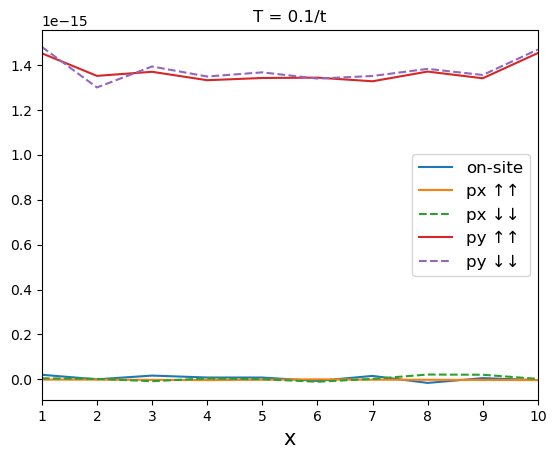

In [16]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(Fuu.px), label="px ↑↑")
plt.plot(x, np.real(Fdd.px), "--", label="px ↓↓")
plt.plot(x, np.imag(Fuu.py), label="py ↑↑")
plt.plot(x, np.imag(Fdd.py), "--", label="py ↓↓")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

In [17]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
mu = 1.5 * t * np.ones(lattice.X)
T = 0.1

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5* t /2
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V=V, V_prime=None,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [18]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.001, maxiter=1000, verbose=False, temperature=T)
F, Fuu, Fdd = H.get_correlations()

Converged after 175 iterations


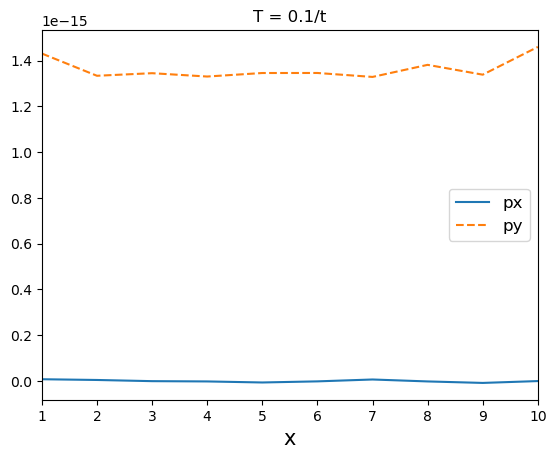

In [19]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F.px), label="px")
plt.plot(x, np.imag(F.py), "--", label="py")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")